In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('used_cars.csv')

In [3]:
df.shape

(4340, 8)

In [4]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [6]:
df = df.drop('name', axis=1)

In [7]:
df['year'].value_counts()

year
2017    466
2015    421
2012    415
2013    386
2014    367
2018    366
2016    357
2011    271
2010    234
2019    195
2009    193
2008    145
2007    134
2006    110
2005     85
2020     48
2004     42
2003     23
2002     21
2001     20
1998     12
2000     12
1999     10
1997      3
1996      2
1995      1
1992      1
Name: count, dtype: int64

In [8]:
df['age'] = 2026 - df['year']

In [9]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,age
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [10]:
df['fuel'].unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [11]:
df['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [12]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [13]:
df['owner'].unique()

array(['First Owner', 'Second Owner', 'Fourth & Above Owner',
       'Third Owner', 'Test Drive Car'], dtype=object)

In [14]:
df = pd.get_dummies(df, columns=['transmission'], drop_first=True)

In [15]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,owner,age,transmission_Manual
0,2007,60000,70000,Petrol,Individual,First Owner,19,True
1,2007,135000,50000,Petrol,Individual,First Owner,19,True
2,2012,600000,100000,Diesel,Individual,First Owner,14,True
3,2017,250000,46000,Petrol,Individual,First Owner,9,True
4,2014,450000,141000,Diesel,Individual,Second Owner,12,True


In [16]:
df = pd.get_dummies(df, columns=['fuel'], drop_first=True)

In [17]:
df.head()

,year,selling_price,km_driven,seller_type,owner,age,transmission_Manual,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol
0,2007,60000,70000,Individual,First Owner,19,True,False,False,False,True
1,2007,135000,50000,Individual,First Owner,19,True,False,False,False,True
2,2012,600000,100000,Individual,First Owner,14,True,True,False,False,False
3,2017,250000,46000,Individual,First Owner,9,True,False,False,False,True
4,2014,450000,141000,Individual,Second Owner,12,True,True,False,False,False


In [18]:
df = pd.get_dummies(df, columns=['seller_type', 'owner'], drop_first=True)

In [19]:
df.head()

,year,selling_price,km_driven,age,transmission_Manual,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007,60000,70000,19,True,False,False,False,True,True,False,False,False,False,False
1,2007,135000,50000,19,True,False,False,False,True,True,False,False,False,False,False
2,2012,600000,100000,14,True,True,False,False,False,True,False,False,False,False,False
3,2017,250000,46000,9,True,False,False,False,True,True,False,False,False,False,False
4,2014,450000,141000,12,True,True,False,False,False,True,False,False,True,False,False


In [20]:
X = df.drop('selling_price', axis=1)

In [21]:
y = df['selling_price']

In [24]:
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
model = DecisionTreeRegressor(max_depth=8, random_state=42)

In [37]:
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=42)

In [38]:
prediction = model.predict(X_test)

In [39]:
mae = mean_absolute_error(y_test, prediction)

In [40]:
mae

175450.78270522924

In [34]:
df['selling_price'].mean()

504127.3117511521

In [41]:
df['selling_price'].max()

8900000

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='selling_price'>

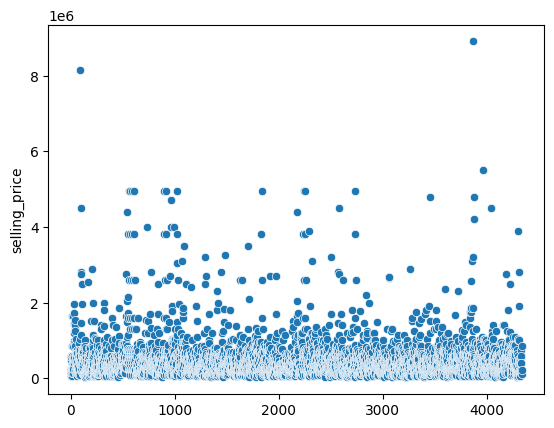

In [47]:
sns.scatterplot(df['selling_price'])

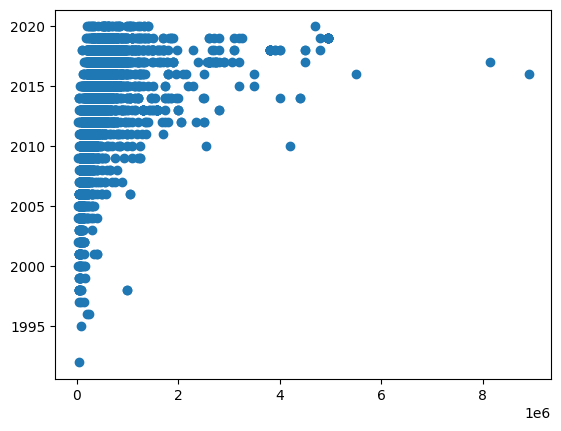

In [48]:
plt.scatter(df['selling_price'], df['year'])

In [49]:
df.shape

(4340, 15)

In [51]:
df = df[df['selling_price'] < 800000]

In [52]:
df.shape

(3734, 15)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
model = DecisionTreeRegressor(max_depth=8, random_state=42)

In [55]:
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=42)

In [56]:
prediction = model.predict(X_test)

In [57]:
mae = mean_absolute_error(y_test, prediction)

In [58]:
mae

175450.78270522924

In [59]:
df['selling_price'].max()

799000

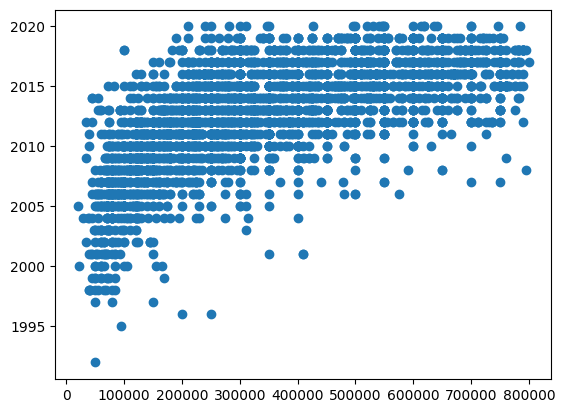

In [60]:
plt.scatter(df['selling_price'], df['year'])

In [61]:
from sklearn.ensemble import RandomForestRegressor

In [62]:
model = RandomForestRegressor()

In [63]:
model.fit(X_train, y_train)

RandomForestRegressor()

In [64]:
prediction = model.predict(X_test)

In [65]:
mae = mean_absolute_error(y_test, prediction)

In [66]:
mae

168969.36178505264